# Mosaic recipe -- speculative farm parcels, geometry only

Draws a full "mosaic" of plausible farm-sized parcels over the eligible water around the real 13-lease cluster, with no MW/turbine/capacity target involved. A scenario is just a random draw of N parcels from that mosaic (N itself sampled per world). Engine lives in `mosaic.py`; this notebook is the read-top-to-bottom version of `dev_scratch/mosaic_prototype.py`.

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import windIO
import xarray as xr
from pyproj import Transformer
from scipy import ndimage
from scipy.spatial import cKDTree
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.vectorized import contains as shapely_contains

import mosaic

DATA_DIR = Path("..") / ".." / "Data"
SLA_PATH = Path("..") / ".." / "WindFarms" / "US_Cluster" / "Data" / "Federal_State_Boundary_SLA.geojson"

FIXED_BOTTOM_MAX_DEPTH = 80.0     # m, fixed-bottom turbine depth limit
BATHY_SMOOTH_M = 2_000.0          # Gaussian-blur the depth grid at this length before thresholding
RESOLUTION_M = 300.0
RADIUS_KM = 150.0                 # search radius from the Vineyard Wind centroid
BUFFER_CELLS = 3                  # ~900m gap between neighboring mosaic parcels
CLUSTER_BUFFER_M = 1_000.0        # margin around the whole real-13-lease union
N_RANGE = (10, 16)                # discrete range for "how many parcels are born" per world
FRAGMENT_AREA_KM2 = 30.0          # leases smaller than this are fragments, excluded from radius calibration
N_WORLDS = 6
BASE_SEED = 7

## 1. Eligibility mask

Two real, physical constraints only: federal water (SLA boundary) and fixed-bottom depth (<80m, Gaussian-smoothed so the cutoff is a clean contour, not raster speckle). The real 13 leases are excluded as one buffered union (closes the gaps between neighboring leases, not just each polygon on its own).

In [2]:
def load_eligibility():
    site_us = windIO.load_yaml(DATA_DIR / "site_us.yaml")
    boundary_polygons = site_us["boundaries"]["polygons"]
    boundary_names = [
        "Vineyard Wind", "Revolution Wind", "SouthCoast Wind", "South Fork Wind",
        "Sunrise Wind South", "Sunrise Wind North", "Revolution Wind North",
        "Vineyard Northeast", "New England Wind 1", "New England Wind 2 South",
        "Beacon Wind", "Bay State Wind South", "Bay State Wind North",
    ]
    lease_templates = {name: Polygon(zip(p["x"], p["y"])) for name, p in zip(boundary_names, boundary_polygons)}

    wind_farm_us = windIO.load_yaml(DATA_DIR / "wind_farm_us.yaml")
    vineyard = next(f for f in wind_farm_us if f["name"] == "Vineyard Wind")
    vineyard_center = np.array([
        np.mean(vineyard["layouts"][0]["coordinates"]["x"]),
        np.mean(vineyard["layouts"][0]["coordinates"]["y"]),
    ])

    bathy = xr.open_dataset(DATA_DIR / "bathymetry_us.nc")
    bathy_xy = np.column_stack([bathy["x"].values, bathy["y"].values])
    bathy_depth = bathy["depth"].values
    bathy_tree = cKDTree(bathy_xy)

    sla_raw = json.load(open(SLA_PATH))["features"][0]["geometry"]["coordinates"]
    lon_min, lon_max, lat_min, lat_max = -73.0, -68.5, 40.0, 43.0
    to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)
    sla_lines_utm = []
    for line in sla_raw:
        pts = np.array(line)
        mask = (pts[:, 0] >= lon_min) & (pts[:, 0] <= lon_max) & (pts[:, 1] >= lat_min) & (pts[:, 1] <= lat_max)
        if mask.sum() < 2:
            continue
        sub = pts[mask]
        x, y = to_utm.transform(sub[:, 0], sub[:, 1])
        sla_lines_utm.append(np.column_stack([x, y]))
    sla_all = np.vstack(sla_lines_utm)
    tangents = np.zeros_like(sla_all)
    offset = 0
    for line in sla_lines_utm:
        n = len(line)
        tangents[offset:offset + n] = np.gradient(line, axis=0)
        offset += n
    sla_tree = cKDTree(sla_all)

    def sla_side(xs, ys):
        pts = np.column_stack([xs, ys])
        _, idx = sla_tree.query(pts)
        vec = pts - sla_all[idx]
        cross = tangents[idx, 0] * vec[:, 1] - tangents[idx, 1] * vec[:, 0]
        return np.sign(cross)

    federal_sign = np.sign(sla_side(np.array([vineyard_center[0]]), np.array([vineyard_center[1]])).mean())

    R = RADIUS_KM * 1000
    margin = 5_000.0
    all_x = np.concatenate([np.array(p["x"]) for p in boundary_polygons])
    all_y = np.concatenate([np.array(p["y"]) for p in boundary_polygons])
    x0 = min(vineyard_center[0] - R - margin, all_x.min() - margin)
    x1 = max(vineyard_center[0] + R + margin, all_x.max() + margin)
    y0 = min(vineyard_center[1] - R - margin, all_y.min() - margin)
    y1 = max(vineyard_center[1] + R + margin, all_y.max() + margin)
    nx = int((x1 - x0) / RESOLUTION_M) + 1
    ny = int((y1 - y0) / RESOLUTION_M) + 1
    gx = x0 + np.arange(nx) * RESOLUTION_M
    gy = y0 + np.arange(ny) * RESOLUTION_M
    GX, GY = np.meshgrid(gx, gy, indexing="xy")
    GXf, GYf = GX.ravel(), GY.ravel()

    _, bidx = bathy_tree.query(np.column_stack([GXf, GYf]))
    depth_grid = bathy_depth[bidx].reshape(GX.shape)
    depth_grid_smooth = ndimage.gaussian_filter(depth_grid, sigma=BATHY_SMOOTH_M / RESOLUTION_M)
    shallow = depth_grid_smooth < FIXED_BOTTOM_MAX_DEPTH
    fed = (sla_side(GXf, GYf) == federal_sign).reshape(GX.shape)
    within_radius = np.hypot(GX - vineyard_center[0], GY - vineyard_center[1]) < R
    eligible = fed & shallow & within_radius

    cluster_shape = unary_union(list(lease_templates.values())).buffer(CLUSTER_BUFFER_M)
    eligible &= ~shapely_contains(cluster_shape, GX, GY)

    eligible_area_km2 = eligible.sum() * (RESOLUTION_M / 1000.0) ** 2
    print(f"Eligibility grid: {nx}x{ny} cells, {eligible_area_km2:,.0f} km2 eligible")
    return dict(eligible=eligible, x0=x0, y0=y0, res=RESOLUTION_M, area_km2=eligible_area_km2,
                lease_templates=lease_templates, vineyard_center=vineyard_center, sla_lines_utm=sla_lines_utm)


env = load_eligibility()

Eligibility grid: 1034x1034 cells, 27,120 km2 eligible


/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_33429/2859639806.py:78: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  eligible &= ~shapely_contains(cluster_shape, GX, GY)


## 2. Parcel radius range, from real lease sizes

`r_min`/`r_max` are the real leases' own equivalent radius (`sqrt(area/pi)`), excluding the 3 non-representative fragment leases under 30 km². This is what makes the mosaic's parcels come out farm-scale instead of an arbitrary size.

In [3]:
def real_farm_radius_range(lease_templates, min_area_km2=FRAGMENT_AREA_KM2):
    areas = np.array([p.area / 1e6 for p in lease_templates.values()])
    r_eq_km = np.sqrt(areas[areas >= min_area_km2] / np.pi)
    return r_eq_km.min() * 1000.0, r_eq_km.max() * 1000.0


R_MIN_M, R_MAX_M = real_farm_radius_range(env["lease_templates"])
print(f"r_min={R_MIN_M/1000:.1f}km, r_max={R_MAX_M/1000:.1f}km")

r_min=4.2km, r_max=13.6km


## 3. Generate worlds

Each world is independent: its own mosaic (`mosaic.generate_mosaic`, dart-throwing + weighted Voronoi + gap buffer + cleanup) and its own target N (sampled from `N_RANGE`), then N parcels drawn at random from that world's mosaic -- a raffle over an already-complete mosaic, not a placement attempt.

In [4]:
worlds = []
for i in range(N_WORLDS):
    seed = BASE_SEED + i
    rng = np.random.default_rng(seed)
    t0 = time.time()
    out = mosaic.generate_mosaic(env["eligible"], env["x0"], env["y0"], env["res"],
                                  R_MIN_M, R_MAX_M, rng, buffer_cells=BUFFER_CELLS)
    elapsed = time.time() - t0

    n_available = len(out["polygons"])
    n_target = int(rng.integers(N_RANGE[0], N_RANGE[1]))
    n_draw = min(n_target, n_available)
    active_idx = set(rng.choice(list(out["polygons"].keys()), size=n_draw, replace=False).tolist()) if n_available else set()

    areas = [p.area / 1e6 for pid, p in out["polygons"].items() if pid in active_idx]
    print(f"seed={seed}: {n_available} parcels available ({elapsed:.2f}s), "
          f"target N={n_target} -> {len(active_idx)} drawn, "
          f"area {min(areas, default=0):.0f}-{max(areas, default=0):.0f} km2")

    worlds.append(dict(polygons=out["polygons"], active_idx=active_idx, seed=seed, n_target=n_target))

seed=7: 103 parcels available (0.72s), target N=12 -> 12 drawn, area 90-304 km2
seed=8: 91 parcels available (0.60s), target N=13 -> 13 drawn, area 109-634 km2
seed=9: 97 parcels available (0.67s), target N=13 -> 13 drawn, area 89-633 km2
seed=10: 83 parcels available (0.55s), target N=12 -> 12 drawn, area 111-582 km2
seed=11: 83 parcels available (0.56s), target N=14 -> 14 drawn, area 124-569 km2
seed=12: 84 parcels available (0.60s), target N=12 -> 12 drawn, area 85-657 km2


## 4. Plot

Left column: the full mosaic for that world (nothing chosen yet). Right column: same mosaic, N parcels drawn (colored), the rest ghosted.

/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_33429/1357185712.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20")


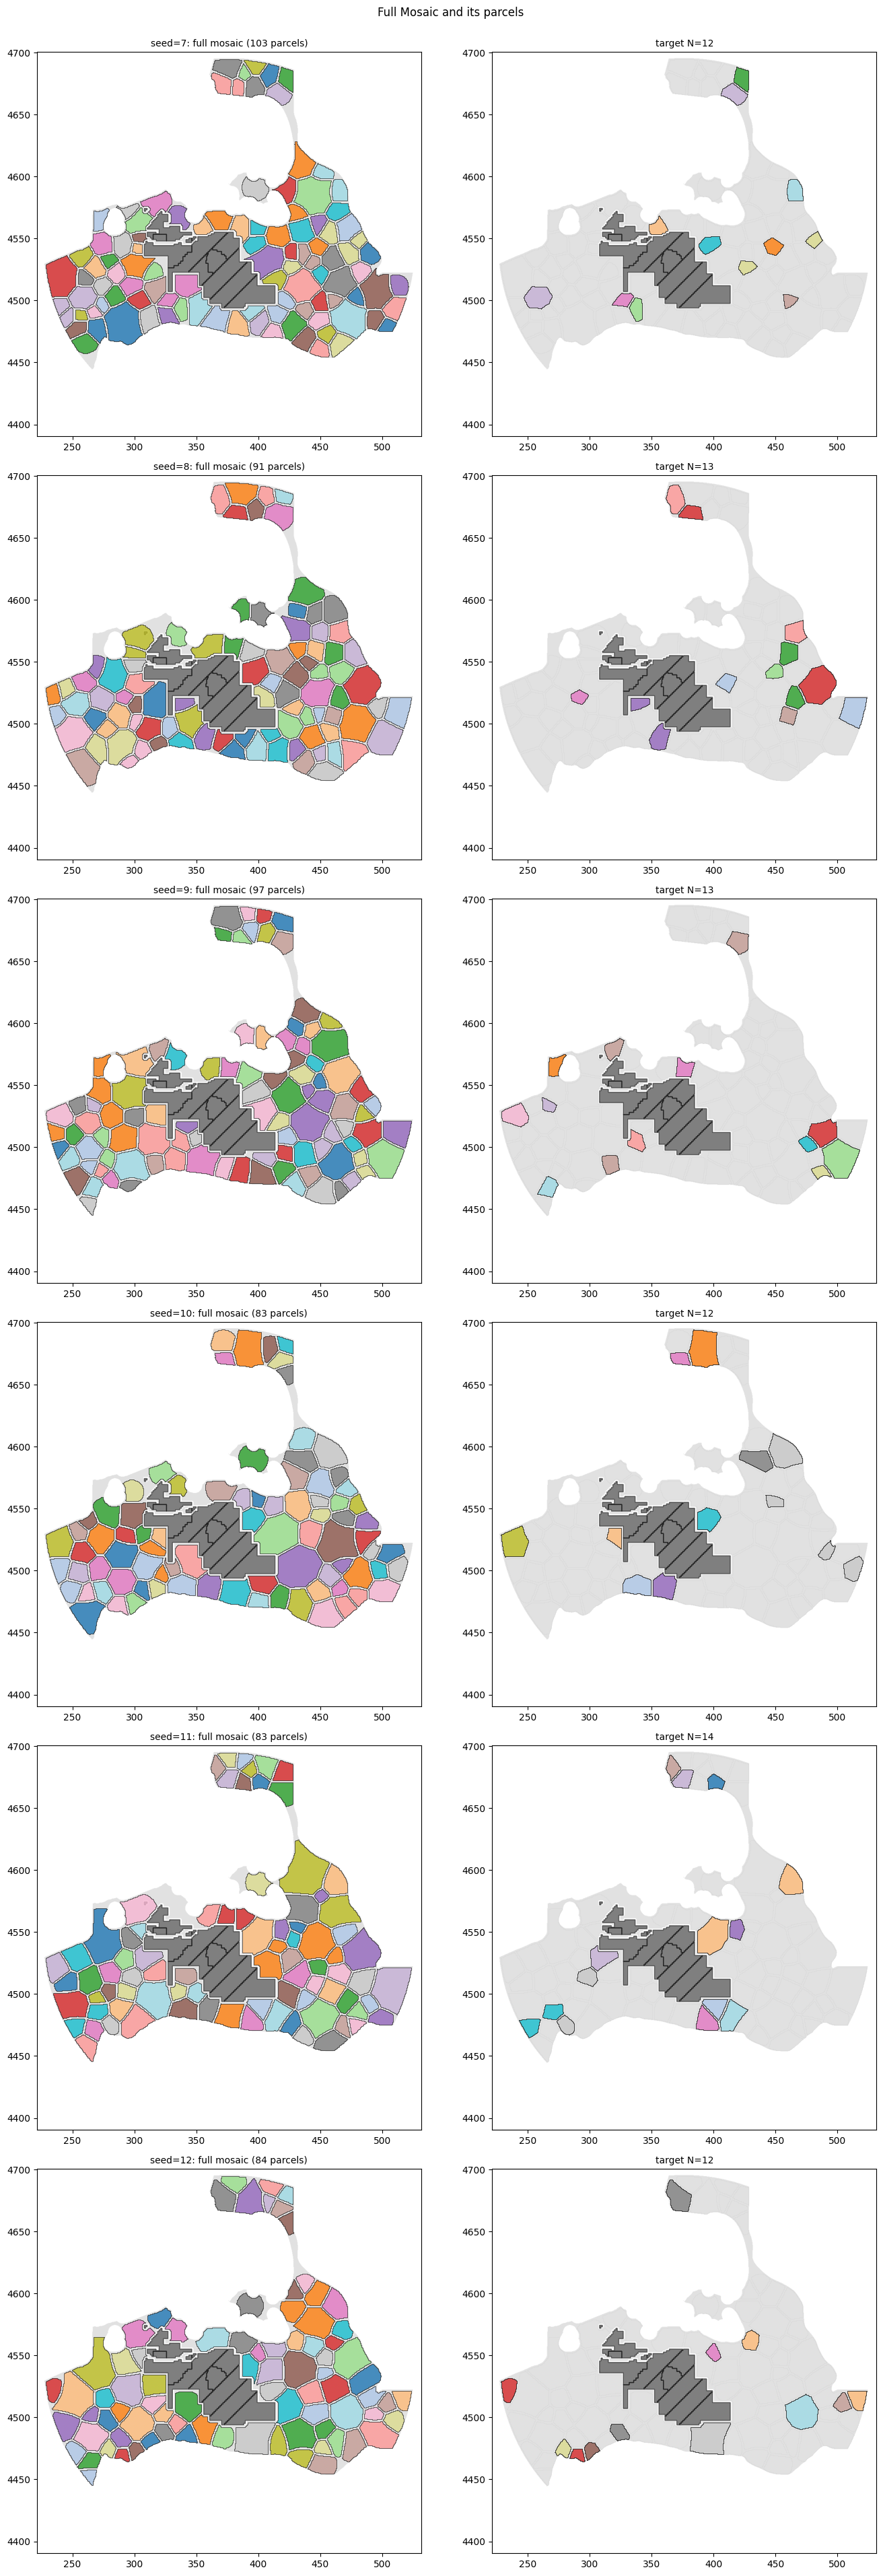

In [13]:
def draw_base(ax, env):
    ax.imshow(env["eligible"], origin="lower", extent=[
        env["x0"] / 1000, (env["x0"] + env["eligible"].shape[1] * env["res"]) / 1000,
        env["y0"] / 1000, (env["y0"] + env["eligible"].shape[0] * env["res"]) / 1000,
    ], cmap="Greys", alpha=0.12, aspect="equal")
    for poly in env["lease_templates"].values():
        bx, by = poly.exterior.xy
        ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color="black", alpha=0.5)
    # ax.scatter(*(env["vineyard_center"] / 1000), marker="*", s=140, color="gold", edgecolor="black", zorder=5)
    ax.set_aspect("equal")


def plot_phase_gallery(env, worlds):
    n = len(worlds)
    fig, axes = plt.subplots(n, 2, figsize=(14, 6.5 * n))
    axes = np.atleast_2d(axes)
    cmap = cm.get_cmap("tab20")

    for row, world in zip(axes, worlds):
        polygons, active_idx, seed, n_target = (world["polygons"], world["active_idx"],
                                                  world["seed"], world["n_target"])
        ax1, ax2 = row

        draw_base(ax1, env)
        for pid, poly in polygons.items():
            if poly.is_empty:
                continue
            bx, by = poly.exterior.xy
            ax1.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cmap(pid % 20),
                      alpha=0.8, edgecolor="black", linewidth=0.5)
        ax1.set_title(f"seed={seed}: full mosaic ({len(polygons)} parcels)", fontsize=10)

        draw_base(ax2, env)
        for pid, poly in polygons.items():
            if poly.is_empty:
                continue
            bx, by = poly.exterior.xy
            if pid in active_idx:
                ax2.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cmap(pid % 20),
                          alpha=0.8, edgecolor="black", linewidth=0.6)
            else:
                ax2.plot(np.array(bx) / 1000, np.array(by) / 1000, "-", color="lightgray", linewidth=0.4, alpha=0.6)
        # ax2.set_title(f"target N={n_target}: {len(active_idx)} drawn", fontsize=10)
        ax2.set_title(f"target N={n_target}", fontsize=10)


    fig.suptitle("Full Mosaic and its parcels ")
                #  f"buffer ~{int(BUFFER_CELLS*RESOLUTION_M)}m, r=[{R_MIN_M/1000:.1f},{R_MAX_M/1000:.1f}]km", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


plot_phase_gallery(env, worlds)

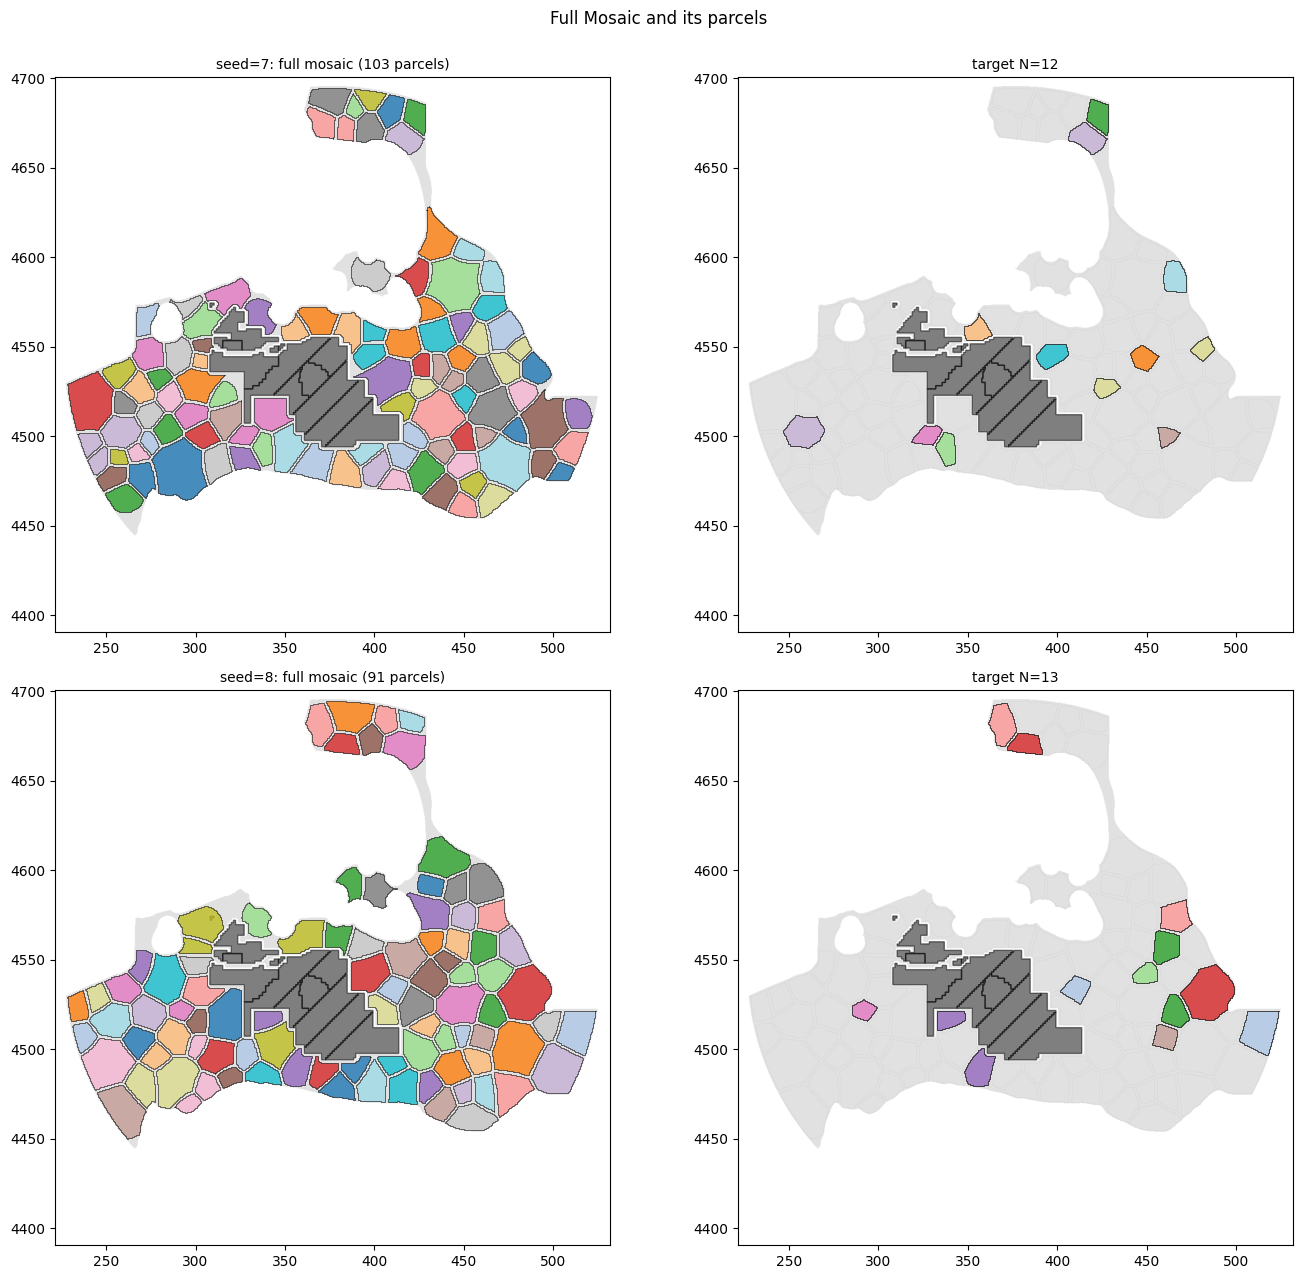

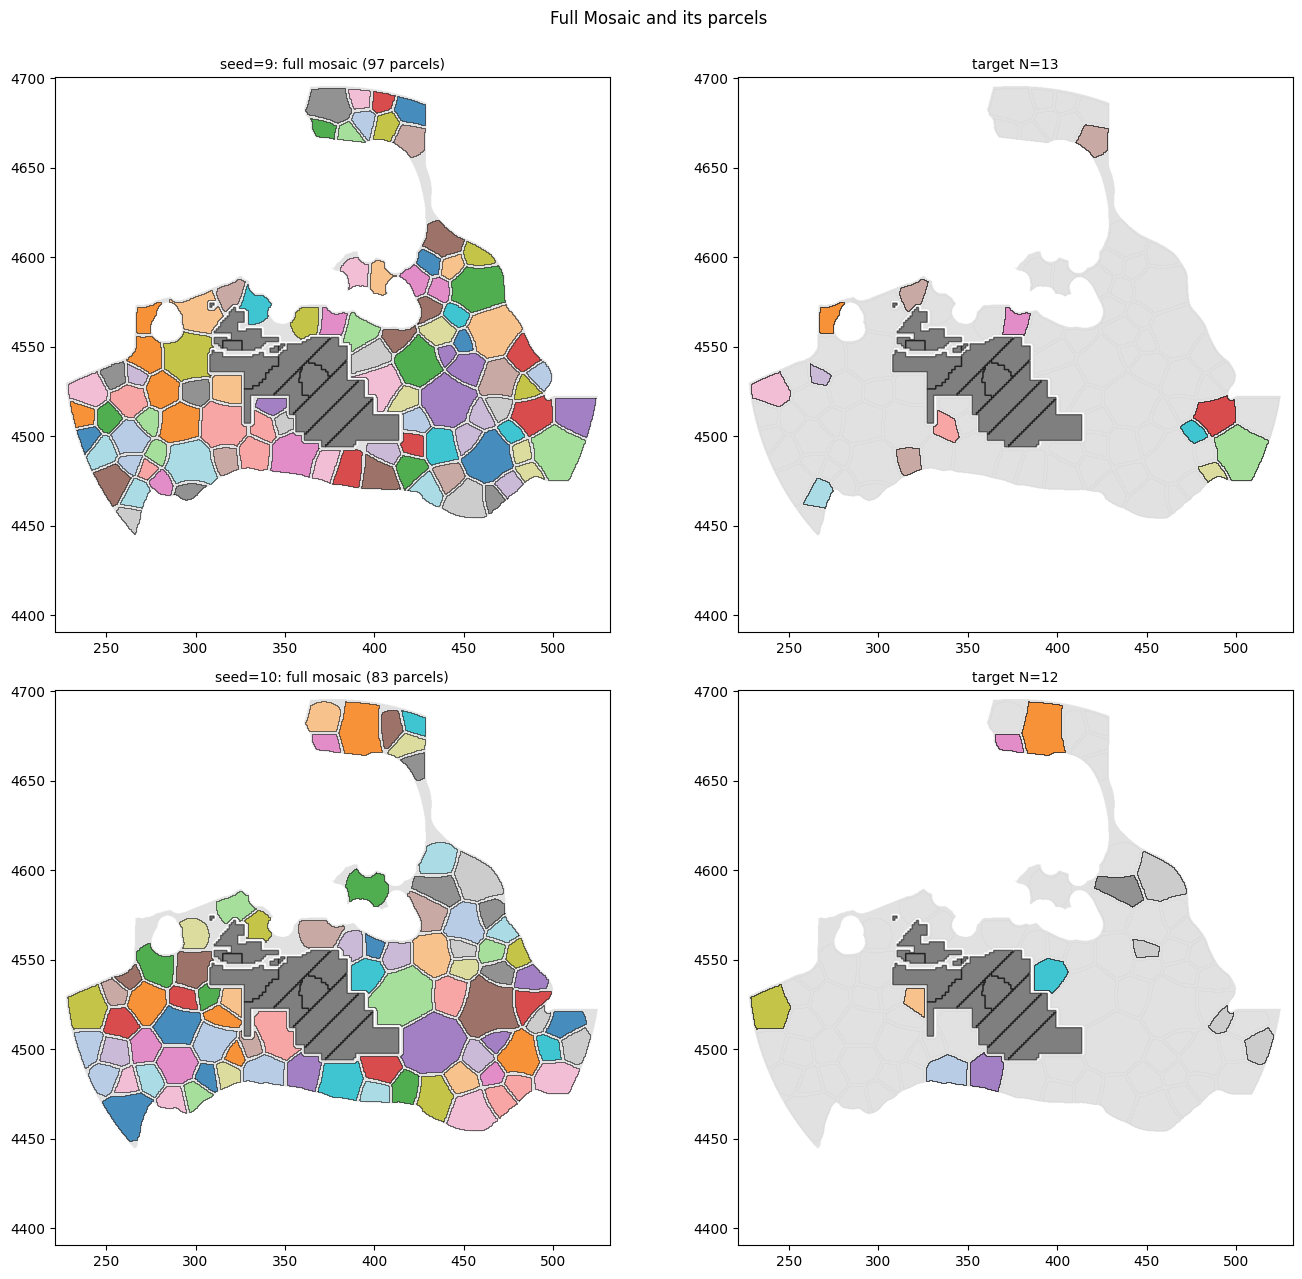

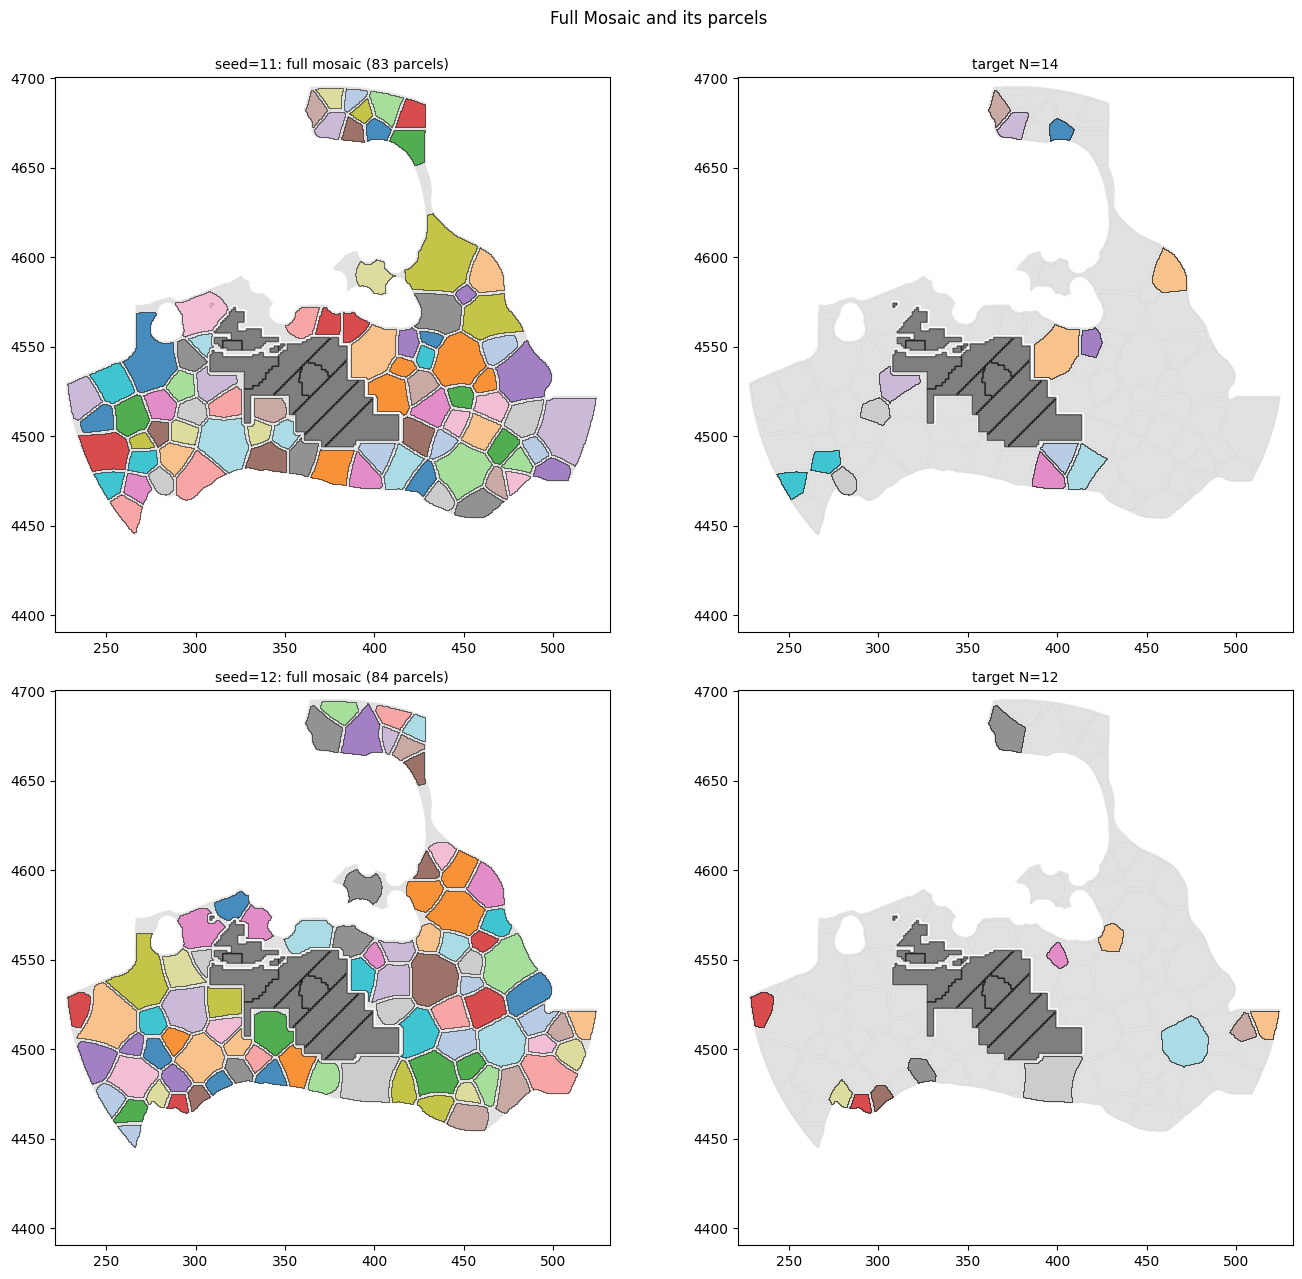

In [15]:
def plot_phase_gallery_chunked(env, worlds, chunk_size=2):
  cmap = plt.colormaps.get_cmap("tab20")

  # Splitting
  for chunk_idx in range(0, len(worlds), chunk_size):
    chunk_worlds = worlds[chunk_idx : chunk_idx + chunk_size]
    n = len(chunk_worlds)

    fig, axes = plt.subplots(n, 2, figsize=(14, 6.5 * n))
    axes = np.atleast_2d(axes)

    for row, world in zip(axes, chunk_worlds):
      polygons = world["polygons"]
      active_idx = world["active_idx"]
      seed = world["seed"]
      n_target = world["n_target"]
      ax1, ax2 = row

      # Left plot: Full mosaic
      draw_base(ax1, env)
      for pid, poly in polygons.items():
        if poly.is_empty:
          continue
        bx, by = poly.exterior.xy
        ax1.fill(
            np.array(bx) / 1000,
            np.array(by) / 1000,
            color=cmap(pid % 20),
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5,
        )
      ax1.set_title(
          f"seed={seed}: full mosaic ({len(polygons)} parcels)", fontsize=10
      )

      # Right plot: Sampled parcels
      draw_base(ax2, env)
      for pid, poly in polygons.items():
        if poly.is_empty:
          continue
        bx, by = poly.exterior.xy
        if pid in active_idx:
          ax2.fill(
              np.array(bx) / 1000,
              np.array(by) / 1000,
              color=cmap(pid % 20),
              alpha=0.8,
              edgecolor="black",
              linewidth=0.6,
          )
        else:
          ax2.plot(
              np.array(bx) / 1000,
              np.array(by) / 1000,
              "-",
              color="lightgray",
              linewidth=0.4,
              alpha=0.6,
          )
      ax2.set_title(f"target N={n_target}", fontsize=10)

    fig.suptitle(
        f"Full Mosaic and its parcels ",
        fontsize=12,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()



plot_phase_gallery_chunked(env, worlds, chunk_size=2)

## 5. Tier scenarios -- low / medium / high

Same idea as Phase 1/2 above, but N's range now depends on a tier instead of one fixed `N_RANGE`. All three tiers draw from the SAME mosaic (one shared "menu"), just how many parcels get picked differs. Each drawn parcel also gets a build-order number (1..N) -- a plain random shuffle for now, no timing model attached yet (that comes later, separately, once a real construction-time distribution is decided).

In [6]:
TIERS = {"low": (2, 6), "medium": (6, 11), "high": (10, 16)}  # (low, high) -- upper bound exclusive


def draw_tier_scenario(mosaic_out, tier_range, rng):
    parcel_ids = list(mosaic_out["polygons"].keys())
    n_draw = min(int(rng.integers(*tier_range)), len(parcel_ids))
    chosen = rng.choice(parcel_ids, size=n_draw, replace=False)
    build_order = rng.permutation(n_draw) + 1  # 1..N, plain shuffle -- no arrival-time model yet
    return {int(pid): int(order) for pid, order in zip(chosen, build_order)}


tier_world = mosaic.generate_mosaic(env["eligible"], env["x0"], env["y0"], env["res"],
                                     R_MIN_M, R_MAX_M, np.random.default_rng(BASE_SEED), buffer_cells=BUFFER_CELLS)
print(f"{len(tier_world['polygons'])} parcels available in this shared mosaic")

tier_scenarios = {}
for tier, seed in zip(TIERS, [101, 102, 103]):
    tier_scenarios[tier] = draw_tier_scenario(tier_world, TIERS[tier], np.random.default_rng(seed))
    print(f"{tier}: {len(tier_scenarios[tier])} farms drawn")

103 parcels available in this shared mosaic
low: 3 farms drawn
medium: 8 farms drawn
high: 13 farms drawn


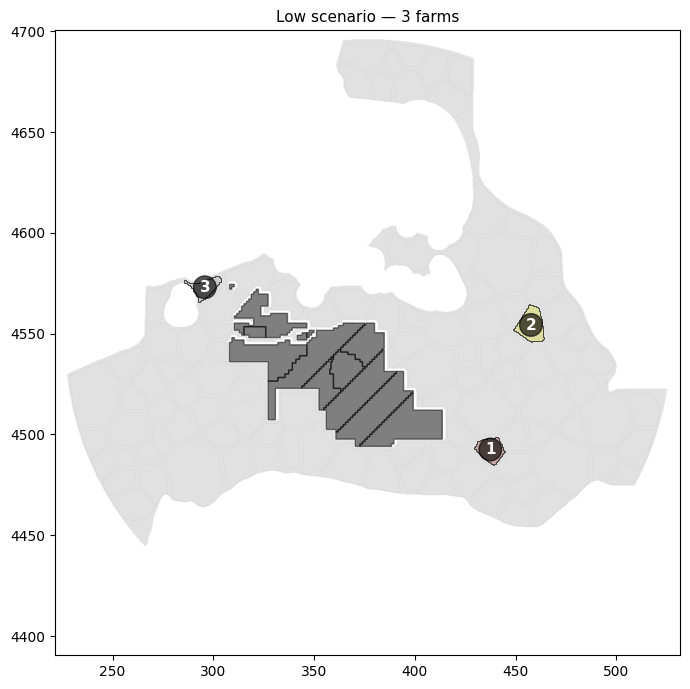

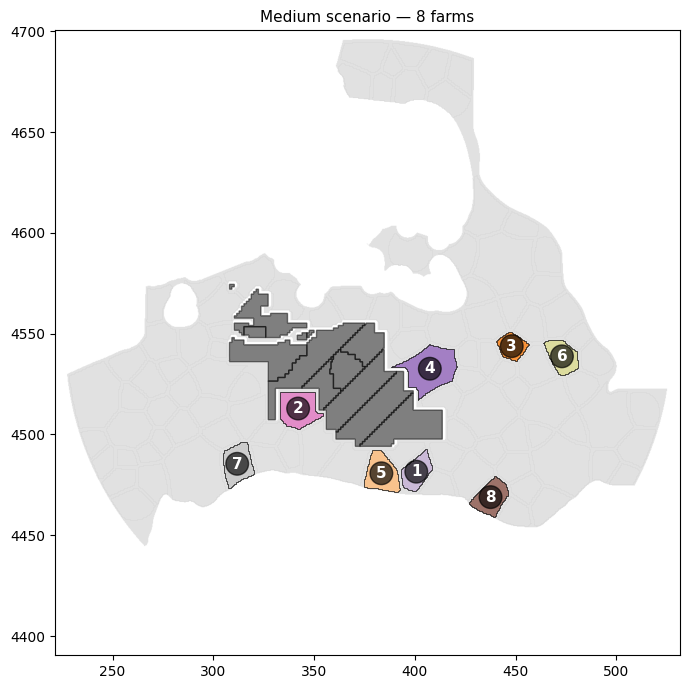

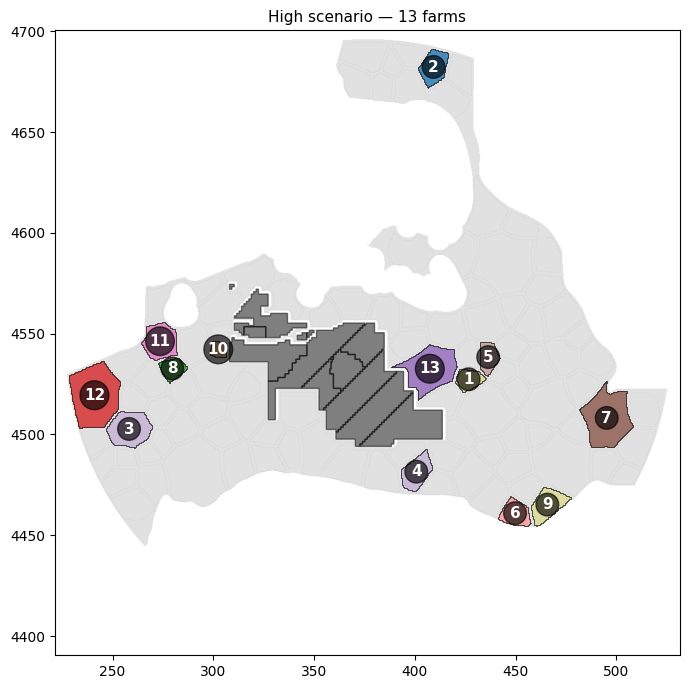

In [18]:
# def plot_tier_scenarios(env, mosaic_out, tier_scenarios):
#     fig, axes = plt.subplots(1, len(tier_scenarios), figsize=(7 * len(tier_scenarios), 7.5))
#     cmap = cm.get_cmap("tab20")

#     for ax, (tier, build_order) in zip(axes, tier_scenarios.items()):
#         draw_base(ax, env)
#         for pid, poly in mosaic_out["polygons"].items():
#             if poly.is_empty:
#                 continue
#             bx, by = poly.exterior.xy
#             if pid in build_order:
#                 ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cmap(pid % 20),
#                         alpha=0.8, edgecolor="black", linewidth=0.6)
#                 cx, cy = poly.centroid.x / 1000, poly.centroid.y / 1000
#                 ax.text(cx, cy, str(build_order[pid]), ha="center", va="center", fontsize=11,
#                         fontweight="bold", color="white",
#                         bbox=dict(boxstyle="circle", facecolor="black", alpha=0.65, pad=0.25))
#             else:
#                 ax.plot(np.array(bx) / 1000, np.array(by) / 1000, "-", color="lightgray", linewidth=0.4, alpha=0.6)
#         ax.set_title(f"{tier} -- {len(build_order)} farms, build order 1-{len(build_order)}", fontsize=11)

#     fig.suptitle("3 Different Scenarios", fontsize=13)
#     fig.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()


# plot_tier_scenarios(env, tier_world, tier_scenarios)


from pathlib import Path


def plot_tier_scenarios_individual(env, mosaic_out, tier_scenarios, save_dir):
  output_dir = Path(save_dir)
  output_dir.mkdir(parents=True, exist_ok=True)
  cmap = plt.colormaps.get_cmap("tab20")

  for tier, build_order in tier_scenarios.items():
    fig, ax = plt.subplots(figsize=(7, 7.5))

    draw_base(ax, env)
    for pid, poly in mosaic_out["polygons"].items():
      if poly.is_empty:
        continue
      bx, by = poly.exterior.xy
      if pid in build_order:
        ax.fill(
            np.array(bx) / 1000,
            np.array(by) / 1000,
            color=cmap(pid % 20),
            alpha=0.8,
            edgecolor="black",
            linewidth=0.6,
        )
        cx, cy = poly.centroid.x / 1000, poly.centroid.y / 1000
        ax.text(
            cx,
            cy,
            str(build_order[pid]),
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white",
            bbox=dict(
                boxstyle="circle", facecolor="black", alpha=0.65, pad=0.25
            ),
        )
      else:
        ax.plot(
            np.array(bx) / 1000,
            np.array(by) / 1000,
            "-",
            color="lightgray",
            linewidth=0.4,
            alpha=0.6,
        )

    ax.set_title(
        f"{tier.capitalize()} scenario — {len(build_order)} farms", fontsize=11
    )
    fig.tight_layout()

    filename = (
        output_dir / f"different_scenario_{tier}_{len(build_order)}_farms.pdf"
    )
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


SAVE_DIR = "/Users/brunoboer/Documents/Risk Study/Main Articles/Graphs"
plot_tier_scenarios_individual(env, tier_world, tier_scenarios, SAVE_DIR)

## Knobs

| Constant | What it controls |
|---|---|
| `R_MIN_M` / `R_MAX_M` | parcel size range -- derived from real lease areas, don't hand-edit; re-run cell 2 if `FRAGMENT_AREA_KM2` changes |
| `BUFFER_CELLS` | gap between neighboring parcels (in 300m grid cells) |
| `CLUSTER_BUFFER_M` | margin excluded around the whole real-13-lease group |
| `BATHY_SMOOTH_M` | how much the <80m depth cutoff is smoothed before use |
| `N_RANGE` | how many parcels a world draws in the Phase 1/2 demo (section 3-4) |
| `N_WORLDS`, `BASE_SEED` | how many independent worlds the Phase 1/2 demo shows, and their seeds |
| `TIERS` | low/medium/high draw ranges for the tier-scenario demo (section 5) |

To try a change: edit the constant in cell 2 (or `TIERS` in section 5's own cell), re-run from there down through the relevant plot cell.